|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

### Problème 2B4

#### La paroi située en x=+B se déplace à la vitesse $V_0$

#### Le problème est identique à 2B3 sauf pour cette condition limite

In [15]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp                         # pour utiliser sympy, on lui donne l'alias sp
from IPython.display import *              # pour utiliser display qui formate les équations
sp.init_printing(use_latex=True)           # pour utiliser LaTeX, formattage de grande qualité 
%matplotlib inline

In [16]:
#
# définition des variables symboliques, ici on utilise la simplification qui est faite
# dans la section 2.3 et dans la section 2.4 ou P est modifié avec la gravité
# de sorte que la pression effective devient p+rho G L ou p-rho g L .
#
x,delta_x,L,W,rho,P_0,P_L,mu,B=sp.symbols('x,delta_x,L,W,rho,P_0,P_L,mu,B')
tau_xz=sp.Function('tau_xz')
phi_xz=sp.Function('phi_xz')
phi_zz=sp.Function('phi_zz')
C1,C2=sp.symbols('C1,C2')

#### On pose le bilan:

In [17]:
# Bilan des forces
bilan=L*W*(phi_xz(x)-phi_xz(x+delta_x))+W*delta_x*(phi_zz(0)-phi_zz(L))
bilan=bilan/(delta_x)
eq=bilan
display(eq)

In [18]:
eq1=sp.limit(eq,delta_x,0)
display(eq1)

In [19]:
eq1=sp.limit(eq,delta_x,0).doit()    # fais la substitution de la variable à la limite
display(eq1)

In [20]:
eq1=eq1/(L*W)
C=sp.symbols('C')
eq1=eq1.subs(phi_zz(0),P_0)     # Les termes de convection phi_zz sont égaux car le débit
eq1=eq1.subs(phi_zz(L),P_L)     # est une constante, on donne donc la valeur 'C'
display(eq1)

In [21]:
eq1=eq1.subs(phi_xz(x),tau_xz(x))    # remplacer phi par tau car la convection est nulle
display(eq1)

In [22]:
eq1=eq1.simplify()                  # simplifie car la division peut être distribuée.
display(eq1)

On insère ensuite la loi de Newton pour remplacer $\tau_{xz}$

In [23]:
#
# Loi de Newton
vz=sp.Function('v_z')(x)
newton=-mu*sp.Derivative(vz,x)
#
# On la substitue dans le bilan
eq2=sp.Eq(eq1.subs(tau_xz(x),newton),0)
display(eq2)

In [24]:
# La solution est faite avec la fonction dsolve de sympy
eq3=sp.dsolve(eq2,vz)

>> Conditions aux limites,
>> en x = B, $v_z=v_0$

>> et en x=-B, $v_z=0$   

#### On ne peut pas dire que le gradient est 0 en x=0, car le profil ne sera plus symétrique.

'profil de vitesse avant de trouver les constantes'

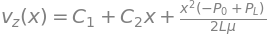

'conditions aux limites'

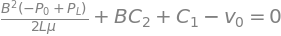

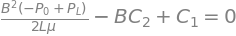

'valeur des constantes'

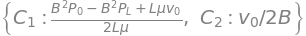

'profil de vitesse après substitution des constantes'

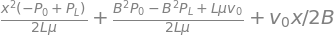

In [25]:
#
# Le rhs est la partie de droite de l'équation, c'est la partie qui nous intéresse
eq4=eq3.rhs
display('profil de vitesse avant de trouver les constantes', eq3)
v_0=sp.symbols('v_0')
condition_1=sp.Eq(eq4.subs(x,B)-v_0,0)
condition_2=sp.Eq(eq4.subs(x,-B),0)                   
display('conditions aux limites',condition_1,condition_2)
constantes=sp.solve([condition_1,condition_2],sp.symbols('C1,C2'))
display('valeur des constantes',constantes)
vz=eq4.subs(constantes)
display('profil de vitesse après substitution des constantes',vz)

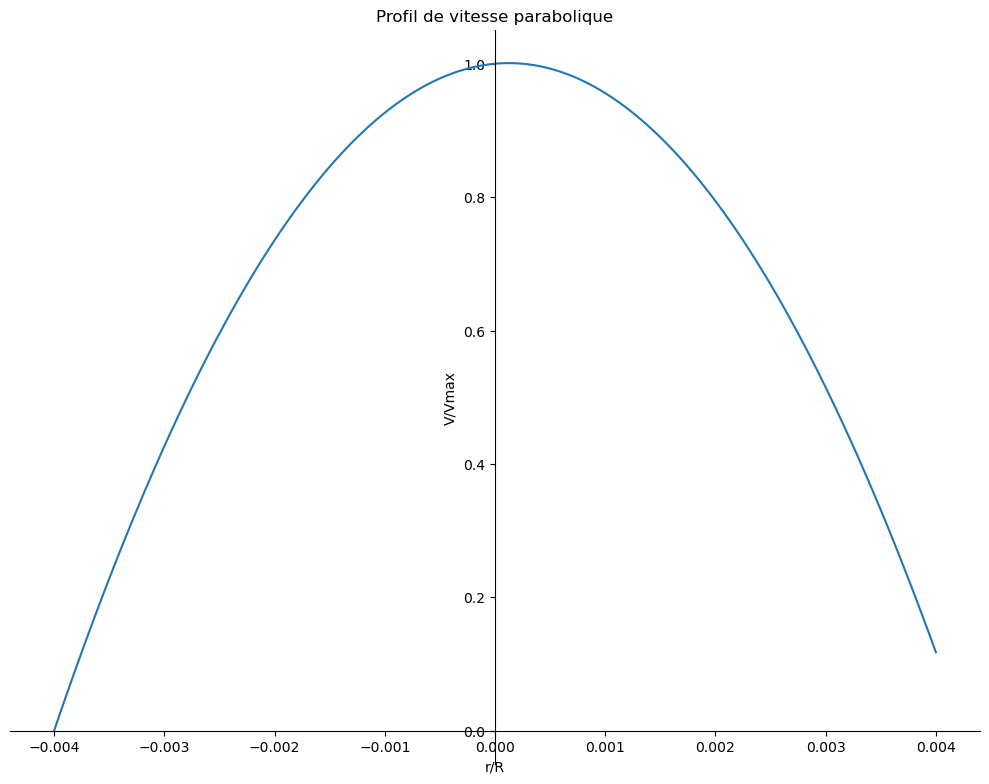

In [26]:
#
# Qu'on peut maintenant tracer, en donnant des valeurs numériques aux paramètres
# Attention, il faut réfléchir un peu et penser aux valeurs données...
#
dico={'B':0.004,'P_0':1000,'P_L':0,'mu':0.001,'L':1,'v_0':1}
vzmax=vz.subs(x,0)
vzmax=vzmax.subs(dico)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10,8   
sp.plot(vz.subs(dico)/vzmax,(x,-B.subs(dico),B.subs(dico)),title='Profil de vitesse parabolique',
       ylabel='V/Vmax',xlabel='r/R');

'Q'

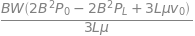

'Hagen-Poiseuille équivalent-slot'

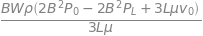

'V_max'

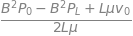

'V_moy'

'V_moy/V_max'

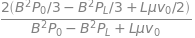

In [27]:
debit_volumique=sp.integrate(vz,(x,-B,B))*W
display('Q',debit_volumique.simplify())
debit_massique=debit_volumique*rho   # Hagen-Poiseuillle
display('Hagen-Poiseuille équivalent-slot',debit_massique.simplify())
vitesse_moyenne=debit_volumique/(2*B*W)
vitesse_maximale=vz.subs(x,0)
display('V_max',vitesse_maximale.simplify())
display('V_moy',vitesse_moyenne.simplify())
display('V_moy/V_max',vitesse_moyenne.simplify()/vitesse_maximale.simplify())  
# Ca vaut la peine d'utiliser la simplification